# Chapter 10: Orthogonality

**Book:** *Linear Algebra with Applications in Machine Learning: From Intuitive Understanding to Python Coding*

---

Orthogonality is the compass of linear algebra: it lets us measure lengths, angles, and distances, decompose vectors into independent components, and find closest approximations. This notebook covers:

1. **Norm and Distance** -- Euclidean norm, vector distance
2. **Dot Product and Orthogonality** -- alignment, angles, perpendicularity
3. **Pythagorean Theorem** -- for orthogonal vectors
4. **Cauchy-Schwarz and Triangle Inequalities** -- fundamental bounds
5. **Orthogonal Complement** -- $S^\perp$, properties, matrix connections
6. **Orthogonal Projection** -- onto lines and subspaces, projection matrices
7. **Least Squares** -- linear and quadratic regression via normal equations
8. **ML Applications** -- PCA, cosine similarity, regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sympy as sp
from scipy.linalg import null_space

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
np.set_printoptions(precision=4, suppress=True)

print("All imports successful.")

All imports successful.


## 10.1 Norm and Distance

The **Euclidean norm** (L2 norm) of $\mathbf{v} \in \mathbb{R}^n$ measures its length:

$$\|\mathbf{v}\| = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}$$

The **distance** between two vectors is $\|\mathbf{u} - \mathbf{v}\|$.

In [2]:
v = np.array([1, 2, 3])
u = np.array([2, -3, 0])

norm_v = np.linalg.norm(v)
norm_u = np.linalg.norm(u)
dist = np.linalg.norm(v - u)

print(f"v = {v}, ||v|| = {norm_v:.4f} (= sqrt(14))")
print(f"u = {u}, ||u|| = {norm_u:.4f} (= sqrt(13))")
print(f"v - u = {v - u}")
print(f"||v - u|| = {dist:.4f} (= sqrt(35))")

# Unit vector (pure direction)
v_hat = v / norm_v
print(f"\nUnit vector: v / ||v|| = {v_hat.round(4)}, norm = {np.linalg.norm(v_hat):.4f}")

v = [1 2 3], ||v|| = 3.7417 (= sqrt(14))
u = [ 2 -3  0], ||u|| = 3.6056 (= sqrt(13))
v - u = [-1  5  3]
||v - u|| = 5.9161 (= sqrt(35))

Unit vector: v / ||v|| = [0.2673 0.5345 0.8018], norm = 1.0000


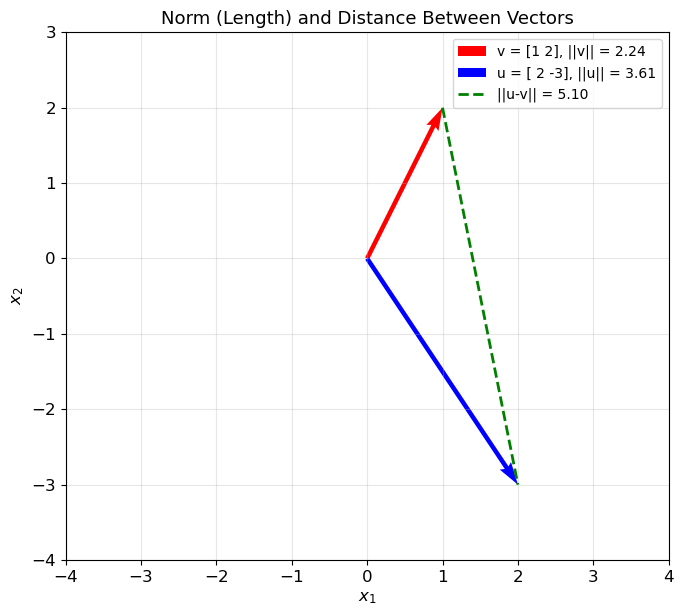

In [3]:
# Visualize norm and distance in 2D
u2 = np.array([2, -3])
v2 = np.array([1, 2])

fig, ax = plt.subplots(figsize=(7, 7))
ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1,
          color='red', linewidth=2.5, label=f'v = {v2}, ||v|| = {np.linalg.norm(v2):.2f}')
ax.quiver(0, 0, u2[0], u2[1], angles='xy', scale_units='xy', scale=1,
          color='blue', linewidth=2.5, label=f'u = {u2}, ||u|| = {np.linalg.norm(u2):.2f}')
ax.plot([v2[0], u2[0]], [v2[1], u2[1]], 'g--', linewidth=2,
        label=f'||u-v|| = {np.linalg.norm(u2-v2):.2f}')

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 3)
ax.set_aspect('equal')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title('Norm (Length) and Distance Between Vectors', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10.2 Dot Product and Orthogonality

The **dot product** measures alignment between two vectors:

$$\mathbf{u} \cdot \mathbf{v} = \sum u_i v_i = \|\mathbf{u}\| \|\mathbf{v}\| \cos\theta$$

Vectors are **orthogonal** (perpendicular) when $\mathbf{u} \cdot \mathbf{v} = 0$.

In [4]:
u = np.array([2, -1, 3])
v = np.array([1, 4, -2])
w = np.array([-8, 3, 2])

pairs = [(u, v, 'u', 'v'), (u, w, 'u', 'w'), (v, w, 'v', 'w')]
for a, b, na, nb in pairs:
    dot = np.dot(a, b)
    cos_theta = dot / (np.linalg.norm(a) * np.linalg.norm(b))
    theta = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))
    orth = "ORTHOGONAL" if abs(dot) < 1e-10 else ""
    print(f"{na} . {nb} = {dot:6.1f},  angle = {theta:6.1f} deg  {orth}")

u . v =   -8.0,  angle =  117.8 deg  
u . w =  -13.0,  angle =  113.3 deg  
v . w =    0.0,  angle =   90.0 deg  ORTHOGONAL


### Properties of the Dot Product

In [5]:
u = np.array([2, -1, 3])
v = np.array([1, 4, -2])
w = np.array([-8, 3, 2])
c = 5.0

properties = [
    ("u . u = ||u||^2",
     np.dot(u, u), np.linalg.norm(u)**2),
    ("u . v = v . u (commutativity)",
     np.dot(u, v), np.dot(v, u)),
    ("u . (v+w) = u.v + u.w (distributivity)",
     np.dot(u, v + w), np.dot(u, v) + np.dot(u, w)),
    ("(cu) . v = c(u . v) (scalar compat)",
     np.dot(c * u, v), c * np.dot(u, v)),
    ("||cu|| = |c| * ||u|| (norm scaling)",
     np.linalg.norm(c * u), abs(c) * np.linalg.norm(u)),
]

print(f"{'Property':50s} {'LHS':>10s} {'RHS':>10s} {'Match':>6s}")
print("-" * 80)
for desc, lhs, rhs in properties:
    print(f"{desc:50s} {lhs:10.4f} {rhs:10.4f} {'PASS' if np.isclose(lhs, rhs) else 'FAIL':>6s}")

Property                                                  LHS        RHS  Match
--------------------------------------------------------------------------------
u . u = ||u||^2                                       14.0000    14.0000   PASS
u . v = v . u (commutativity)                         -8.0000    -8.0000   PASS
u . (v+w) = u.v + u.w (distributivity)               -21.0000   -21.0000   PASS
(cu) . v = c(u . v) (scalar compat)                  -40.0000   -40.0000   PASS
||cu|| = |c| * ||u|| (norm scaling)                   18.7083    18.7083   PASS


## 10.3 Pythagorean Theorem for Vectors

If $\mathbf{u} \cdot \mathbf{v} = 0$ (orthogonal), then:

$$\|\mathbf{u} + \mathbf{v}\|^2 = \|\mathbf{u}\|^2 + \|\mathbf{v}\|^2$$

In [6]:
u = np.array([1, 0])
v = np.array([0, 2])

print(f"u = {u}, v = {v}")
print(f"u . v = {np.dot(u, v)} (orthogonal)")
print(f"\n||u+v||^2 = {np.linalg.norm(u + v)**2:.2f}")
print(f"||u||^2 + ||v||^2 = {np.linalg.norm(u)**2 + np.linalg.norm(v)**2:.2f}")
print(f"Pythagorean theorem holds: {np.isclose(np.linalg.norm(u+v)**2, np.linalg.norm(u)**2 + np.linalg.norm(v)**2)}")

# Non-orthogonal case: cross-term appears
a = np.array([1, 1])
b = np.array([1, 0])
print(f"\nNon-orthogonal: a = {a}, b = {b}, a.b = {np.dot(a, b)}")
print(f"||a+b||^2 = {np.linalg.norm(a+b)**2:.2f}")
print(f"||a||^2 + ||b||^2 = {np.linalg.norm(a)**2 + np.linalg.norm(b)**2:.2f}")
print(f"Difference = 2*(a.b) = {2*np.dot(a, b):.2f}")

u = [1 0], v = [0 2]
u . v = 0 (orthogonal)

||u+v||^2 = 5.00
||u||^2 + ||v||^2 = 5.00
Pythagorean theorem holds: True

Non-orthogonal: a = [1 1], b = [1 0], a.b = 1
||a+b||^2 = 5.00
||a||^2 + ||b||^2 = 3.00
Difference = 2*(a.b) = 2.00


## 10.4 Cauchy-Schwarz and Triangle Inequalities

**Cauchy-Schwarz:** $|\mathbf{u} \cdot \mathbf{v}| \leq \|\mathbf{u}\| \cdot \|\mathbf{v}\|$ (equality iff $\mathbf{u} = c\mathbf{v}$)

**Triangle:** $\|\mathbf{u} + \mathbf{v}\| \leq \|\mathbf{u}\| + \|\mathbf{v}\|$ (shortest path is direct)

In [7]:
u = np.array([2, -3, 4])
v = np.array([1, -2, -5])

dot_abs = abs(np.dot(u, v))
norm_prod = np.linalg.norm(u) * np.linalg.norm(v)
norm_sum = np.linalg.norm(u + v)
sum_norms = np.linalg.norm(u) + np.linalg.norm(v)

print("Cauchy-Schwarz Inequality:")
print(f"  |u . v| = {dot_abs:.4f}")
print(f"  ||u|| * ||v|| = {norm_prod:.4f}")
print(f"  {dot_abs:.4f} <= {norm_prod:.4f}? {dot_abs <= norm_prod + 1e-10}")

print(f"\nTriangle Inequality:")
print(f"  ||u + v|| = {norm_sum:.4f}")
print(f"  ||u|| + ||v|| = {sum_norms:.4f}")
print(f"  {norm_sum:.4f} <= {sum_norms:.4f}? {norm_sum <= sum_norms + 1e-10}")

Cauchy-Schwarz Inequality:
  |u . v| = 12.0000
  ||u|| * ||v|| = 29.4958
  12.0000 <= 29.4958? True

Triangle Inequality:
  ||u + v|| = 5.9161
  ||u|| + ||v|| = 10.8624
  5.9161 <= 10.8624? True


In [8]:
# Equality in Cauchy-Schwarz: when u = c*v (parallel)
u_par = np.array([2, 4, 6])
v_par = np.array([1, 2, 3])  # u = 2*v

print("Parallel vectors (u = 2v):")
print(f"  |u . v| = {abs(np.dot(u_par, v_par)):.4f}")
print(f"  ||u||*||v|| = {np.linalg.norm(u_par)*np.linalg.norm(v_par):.4f}")
print(f"  Equal? {np.isclose(abs(np.dot(u_par, v_par)), np.linalg.norm(u_par)*np.linalg.norm(v_par))}")

Parallel vectors (u = 2v):
  |u . v| = 28.0000
  ||u||*||v|| = 28.0000
  Equal? True


## 10.5 Orthogonal Complement

The **orthogonal complement** of a subspace $S \subseteq \mathbb{R}^n$ is:

$$S^\perp = \{\mathbf{v} \in \mathbb{R}^n \mid \mathbf{v} \cdot \mathbf{w} = 0 \ \forall\ \mathbf{w} \in S\}$$

Key properties: $\dim(S) + \dim(S^\perp) = n$, $\text{Row}(A)^\perp = \text{Null}(A)$, $\text{Col}(A)^\perp = \text{Null}(A^T)$.

In [9]:
# Orthogonal complement of S = span{[1,1,-1,4], [1,-1,1,2]} in R^4
# S^perp = Null(A) where A has the spanning vectors as rows
A = np.array([[1, 1, -1, 4],
              [1, -1, 1, 2]], dtype=float)

S_perp = null_space(A)
print(f"S = span of rows of A ({A.shape[0]}x{A.shape[1]})")
print(f"dim(S) = {np.linalg.matrix_rank(A)}")
print(f"dim(S^perp) = {S_perp.shape[1]}")
print(f"dim(S) + dim(S^perp) = {np.linalg.matrix_rank(A) + S_perp.shape[1]} = n = {A.shape[1]}")
print(f"\nBasis for S^perp (columns):\n{S_perp.round(4)}")

# Verify orthogonality
print(f"\nVerify: A @ S_perp =\n{(A @ S_perp).round(10)}  (should be zero)")

S = span of rows of A (2x4)
dim(S) = 2
dim(S^perp) = 2
dim(S) + dim(S^perp) = 4 = n = 4

Basis for S^perp (columns):
[[ 0.01   -0.9258]
 [ 0.7087 -0.1466]
 [ 0.7054  0.1619]
 [-0.0033  0.3086]]

Verify: A @ S_perp =
[[ 0. -0.]
 [-0. -0.]]  (should be zero)


In [10]:
# SymPy for exact computation
A_sym = sp.Matrix([[1, 1, -1, 4],
                   [1, -1, 1, 2]])
ns = A_sym.nullspace()
print("Exact basis for S^perp:")
for v in ns:
    print(f"  {v.T}")

Exact basis for S^perp:
  Matrix([[0, 1, 1, 0]])
  Matrix([[-3, -1, 0, 1]])


### Row(A)$^\perp$ = Null(A) and Col(A)$^\perp$ = Null(A$^T$)

In [11]:
A = np.array([[1, 2, 3],
              [4, 5, 6]], dtype=float)

print(f"A ({A.shape[0]}x{A.shape[1]}), rank = {np.linalg.matrix_rank(A)}")

# Row(A)^perp = Null(A)
ns_A = null_space(A)
print(f"\ndim(Row(A)) = {np.linalg.matrix_rank(A)}, dim(Null(A)) = {ns_A.shape[1]}")
print(f"Sum = {np.linalg.matrix_rank(A) + ns_A.shape[1]} = n = {A.shape[1]}")

# Col(A)^perp = Null(A^T)
ns_AT = null_space(A.T)
print(f"\ndim(Col(A)) = {np.linalg.matrix_rank(A)}, dim(Null(A^T)) = {ns_AT.shape[1]}")
print(f"Sum = {np.linalg.matrix_rank(A) + ns_AT.shape[1]} = m = {A.shape[0]}")

# Verify: null space vectors are orthogonal to rows
if ns_A.shape[1] > 0:
    print(f"\nA @ Null(A) =\n{(A @ ns_A).round(10)}  (zeros confirm orthogonality)")

A (2x3), rank = 2

dim(Row(A)) = 2, dim(Null(A)) = 1
Sum = 3 = n = 3

dim(Col(A)) = 2, dim(Null(A^T)) = 0
Sum = 2 = m = 2

A @ Null(A) =
[[ 0.]
 [-0.]]  (zeros confirm orthogonality)


## 10.6 Orthogonal Projection

The **projection** of $\mathbf{v}$ onto a line $\text{span}(\mathbf{u})$ is:

$$\text{proj}_{\mathbf{u}}(\mathbf{v}) = \frac{\mathbf{v} \cdot \mathbf{u}}{\mathbf{u} \cdot \mathbf{u}} \mathbf{u}$$

The residual $\mathbf{v} - \text{proj}_{\mathbf{u}}(\mathbf{v})$ is orthogonal to $\mathbf{u}$.

In [12]:
def proj_onto_vector(v, u):
    """Project v onto the line spanned by u."""
    return (np.dot(v, u) / np.dot(u, u)) * u

v = np.array([4, 1])
u = np.array([2, 1])

proj = proj_onto_vector(v, u)
error = v - proj

print(f"v = {v}")
print(f"u = {u}")
print(f"proj_u(v) = {proj}")
print(f"error = v - proj = {error}")
print(f"error . u = {np.dot(error, u):.6f}  (should be 0: orthogonal)")
print(f"||error|| = {np.linalg.norm(error):.4f}  (distance from v to line)")

v = [4 1]
u = [2 1]
proj_u(v) = [3.6 1.8]
error = v - proj = [ 0.4 -0.8]
error . u = -0.000000  (should be 0: orthogonal)
||error|| = 0.8944  (distance from v to line)


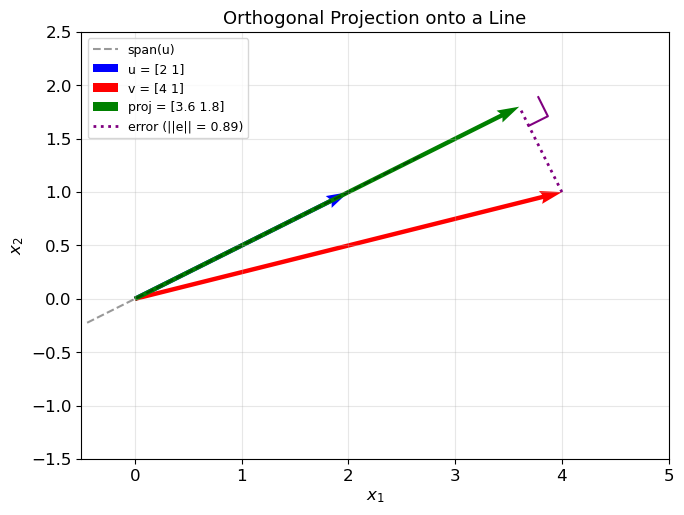

In [13]:
# Visualize projection
fig, ax = plt.subplots(figsize=(7, 7))

# Line (span of u)
t = np.linspace(-0.5, 3, 100)
u_dir = u / np.linalg.norm(u)
ax.plot(t * u_dir[0], t * u_dir[1], 'k--', linewidth=1.5, alpha=0.4, label='span(u)')

ax.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1,
          color='blue', linewidth=2.5, label=f'u = {u}')
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
          color='red', linewidth=2.5, label=f'v = {v}')
ax.quiver(0, 0, proj[0], proj[1], angles='xy', scale_units='xy', scale=1,
          color='green', linewidth=2.5, label=f'proj = {proj}')
ax.plot([v[0], proj[0]], [v[1], proj[1]], 'purple', linewidth=2, linestyle=':',
        label=f'error (||e|| = {np.linalg.norm(error):.2f})')

# Right-angle marker
s = 0.2
perp = error / np.linalg.norm(error) * s
along = u_dir * s
corner = np.array([proj + perp, proj + perp + along, proj + along])
ax.plot(corner[:, 0], corner[:, 1], 'purple', linewidth=1.5)

ax.set_xlim(-0.5, 5)
ax.set_ylim(-1.5, 2.5)
ax.set_aspect('equal')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title('Orthogonal Projection onto a Line', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Vector Decomposition: Parallel + Perpendicular Components

In [14]:
# Decompose u = [3,4,5] relative to v = [1,0,1]
u = np.array([3, 4, 5])
v = np.array([1, 0, 1])

u_parallel = proj_onto_vector(u, v)
u_perp = u - u_parallel

print(f"u = {u}")
print(f"v = {v}")
print(f"u_parallel = proj_v(u) = {u_parallel}")
print(f"u_perp = u - u_parallel = {u_perp}")
print(f"\nVerify: u_parallel + u_perp = {u_parallel + u_perp}  (should be u)")
print(f"u_perp . v = {np.dot(u_perp, v):.6f}  (should be 0)")

u = [3 4 5]
v = [1 0 1]
u_parallel = proj_v(u) = [4. 0. 4.]
u_perp = u - u_parallel = [-1.  4.  1.]

Verify: u_parallel + u_perp = [3. 4. 5.]  (should be u)
u_perp . v = 0.000000  (should be 0)


### Projection onto a Subspace (Matrix Formula)

For a subspace spanned by columns of $A \in \mathbb{R}^{n \times k}$, the projection matrix is:

$$P_S = A(A^TA)^{-1}A^T$$

Properties: $P_S^2 = P_S$ (idempotent), $P_S^T = P_S$ (symmetric).

In [15]:
# Projection onto span{[1,1,0], [0,1,1]}
A = np.array([[1, 0],
              [1, 1],
              [0, 1]], dtype=float)

P = A @ np.linalg.inv(A.T @ A) @ A.T
print(f"Projection matrix P =\n{P.round(4)}")
print(f"\nP^2 = P (idempotent)? {np.allclose(P @ P, P)}")
print(f"P^T = P (symmetric)?  {np.allclose(P, P.T)}")

v = np.array([2, 2, 3])
proj = P @ v
error = v - proj
print(f"\nv = {v}")
print(f"proj_S(v) = {proj.round(4)}")
print(f"error = {error.round(4)}")
print(f"error . col1 = {np.dot(error, A[:, 0]):.6f}")
print(f"error . col2 = {np.dot(error, A[:, 1]):.6f}")
print("Error is orthogonal to the subspace.")

Projection matrix P =
[[ 0.6667  0.3333 -0.3333]
 [ 0.3333  0.6667  0.3333]
 [-0.3333  0.3333  0.6667]]

P^2 = P (idempotent)? True
P^T = P (symmetric)?  True

v = [2 2 3]
proj_S(v) = [1. 3. 2.]
error = [ 1. -1.  1.]
error . col1 = 0.000000
error . col2 = 0.000000
Error is orthogonal to the subspace.


## 10.7 Least Squares Approximation

Given an overdetermined system $C\mathbf{a} = \mathbf{y}$ (more equations than unknowns), the least squares solution minimizes $\|\mathbf{y} - C\mathbf{a}\|^2$ via the **normal equations**:

$$\mathbf{a} = (C^TC)^{-1}C^T\mathbf{y}$$

### Linear Regression: $y = a_0 + a_1 x$

In [16]:
# Data: (1,62), (3,54), (4,50), (5,48), (7,40)
x_data = np.array([1, 3, 4, 5, 7])
y_data = np.array([62, 54, 50, 48, 40])

# Design matrix for y = a0 + a1*x
C = np.column_stack([np.ones_like(x_data), x_data])

# Normal equations
a = np.linalg.inv(C.T @ C) @ C.T @ y_data

print(f"Design matrix C:\n{C}")
print(f"\nC^T C =\n{C.T @ C}")
print(f"C^T y = {C.T @ y_data}")
print(f"\nCoefficients: a0 = {a[0]:.2f}, a1 = {a[1]:.2f}")
print(f"Best-fit line: y = {a[0]:.1f} + ({a[1]:.1f})x")

# Verify error is orthogonal to column space
y_pred = C @ a
error = y_data - y_pred
print(f"\nError orthogonal to columns of C?")
print(f"  C^T @ error = {(C.T @ error).round(10)}  (should be [0, 0])")

Design matrix C:
[[1 1]
 [1 3]
 [1 4]
 [1 5]
 [1 7]]

C^T C =
[[  5  20]
 [ 20 100]]
C^T y = [254 944]

Coefficients: a0 = 65.20, a1 = -3.60
Best-fit line: y = 65.2 + (-3.6)x

Error orthogonal to columns of C?
  C^T @ error = [0. 0.]  (should be [0, 0])


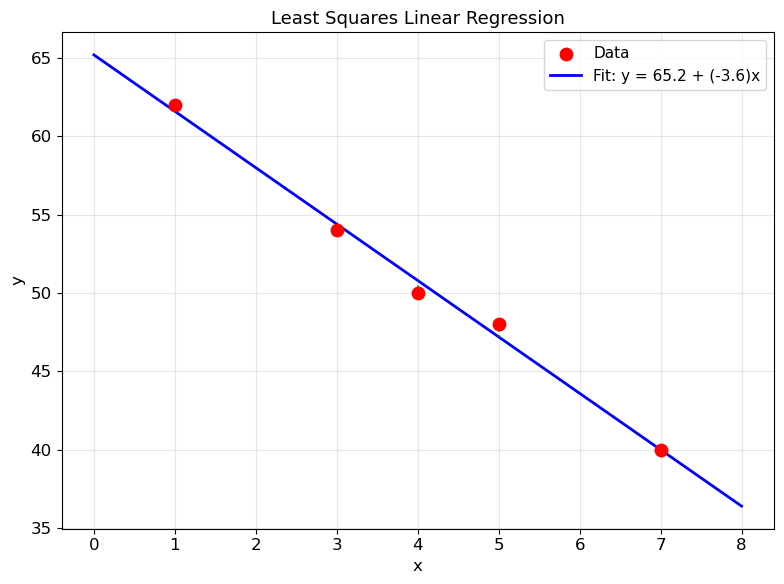

In [17]:
# Visualize the linear fit
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x_data, y_data, color='red', s=80, zorder=5, label='Data')

x_line = np.linspace(0, 8, 100)
ax.plot(x_line, a[0] + a[1] * x_line, 'b-', linewidth=2,
        label=f'Fit: y = {a[0]:.1f} + ({a[1]:.1f})x')

# Residuals
for xi, yi, yp in zip(x_data, y_data, y_pred):
    ax.plot([xi, xi], [yi, yp], 'g--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Least Squares Linear Regression', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Quadratic Regression: $y = a_0 + a_1 x + a_2 x^2$

Quadratic coefficients: a0=49.20, a1=20.40, a2=-3.00
Model: y = 49.2 + 20.4x + (-3.0)x^2

Prediction at x = 2.5: y = 81.45


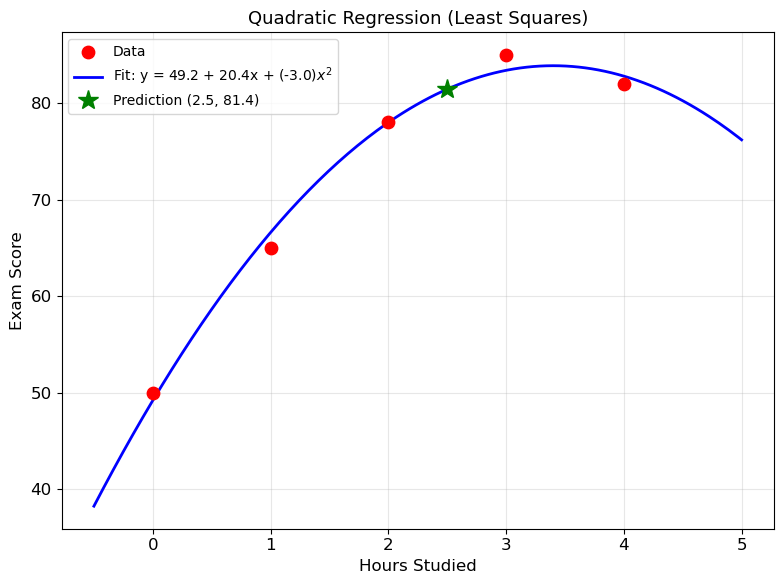

In [18]:
# Data: hours studied vs exam score
x_q = np.array([0, 1, 2, 3, 4])
y_q = np.array([50, 65, 78, 85, 82])

# Design matrix for quadratic
C_q = np.column_stack([np.ones_like(x_q), x_q, x_q**2])
a_q = np.linalg.inv(C_q.T @ C_q) @ C_q.T @ y_q

print(f"Quadratic coefficients: a0={a_q[0]:.2f}, a1={a_q[1]:.2f}, a2={a_q[2]:.2f}")
print(f"Model: y = {a_q[0]:.1f} + {a_q[1]:.1f}x + ({a_q[2]:.1f})x^2")

# Prediction
x_new = 2.5
y_new = a_q[0] + a_q[1]*x_new + a_q[2]*x_new**2
print(f"\nPrediction at x = {x_new}: y = {y_new:.2f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x_q, y_q, color='red', s=80, zorder=5, label='Data')
x_smooth = np.linspace(-0.5, 5, 200)
y_smooth = a_q[0] + a_q[1]*x_smooth + a_q[2]*x_smooth**2
ax.plot(x_smooth, y_smooth, 'b-', linewidth=2,
        label=f'Fit: y = {a_q[0]:.1f} + {a_q[1]:.1f}x + ({a_q[2]:.1f})$x^2$')
ax.plot(x_new, y_new, 'g*', markersize=15, label=f'Prediction ({x_new}, {y_new:.1f})')

ax.set_xlabel('Hours Studied')
ax.set_ylabel('Exam Score')
ax.set_title('Quadratic Regression (Least Squares)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Multivariable Regression: $y = a_0 + a_1 x_1 + a_2 x_2$

In [19]:
# Simple multivariable example
np.random.seed(42)
n = 20
x1 = np.random.uniform(1, 10, n)
x2 = np.random.uniform(1, 5, n)
y_mv = 3 + 2*x1 - 1.5*x2 + np.random.randn(n) * 0.5  # true model + noise

X = np.column_stack([np.ones(n), x1, x2])
a_mv = np.linalg.inv(X.T @ X) @ X.T @ y_mv

print(f"True coefficients:    a0=3.0, a1=2.0, a2=-1.5")
print(f"Recovered coefficients: a0={a_mv[0]:.3f}, a1={a_mv[1]:.3f}, a2={a_mv[2]:.3f}")

# Residual orthogonality
residuals = y_mv - X @ a_mv
print(f"\nX^T @ residuals = {(X.T @ residuals).round(10)}  (all ~0: orthogonal)")
print(f"RSS = {np.sum(residuals**2):.4f}")

True coefficients:    a0=3.0, a1=2.0, a2=-1.5
Recovered coefficients: a0=2.252, a1=2.036, a2=-1.362

X^T @ residuals = [-0. -0. -0.]  (all ~0: orthogonal)
RSS = 3.3681


## 10.8 Orthogonality in Machine Learning

### Cosine Similarity

Cosine similarity measures how aligned two vectors are, ignoring magnitude. It is the normalized dot product:

$$\text{cosine\_sim}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \|\mathbf{v}\|}$$

In [20]:
def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# Word vectors (simplified)
king = np.array([0.9, 0.1, 0.8])
queen = np.array([0.85, 0.15, 0.75])
apple = np.array([0.1, 0.9, 0.05])

print("Cosine similarity (higher = more similar):")
print(f"  king vs queen:  {cosine_similarity(king, queen):.4f}  (very similar)")
print(f"  king vs apple:  {cosine_similarity(king, apple):.4f}  (dissimilar)")
print(f"  queen vs apple: {cosine_similarity(queen, apple):.4f}  (dissimilar)")

Cosine similarity (higher = more similar):
  king vs queen:  0.9988  (very similar)
  king vs apple:  0.2008  (dissimilar)
  queen vs apple: 0.2483  (dissimilar)


### PCA: Orthogonal Principal Components

PC1 . PC2 = 0.000000  (orthogonal)
Variance: PC1 = 4.64 (92%), PC2 = 0.41 (8%)


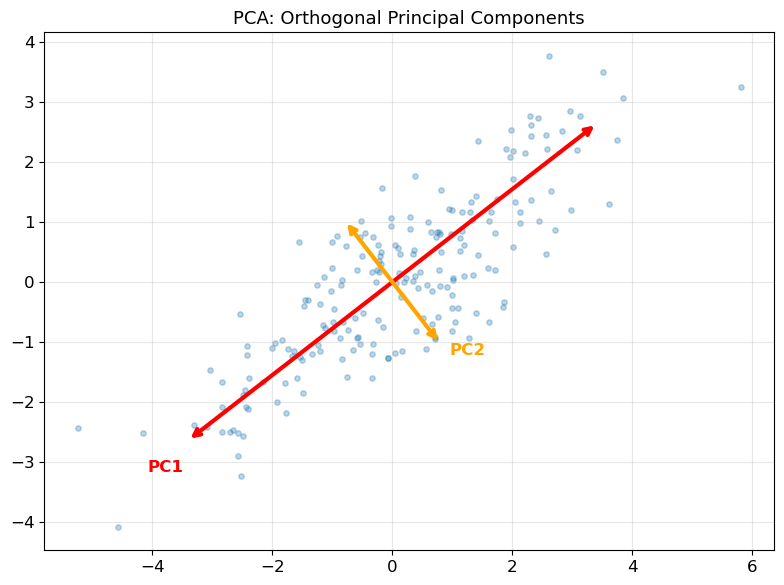

In [21]:
np.random.seed(7)
cov = np.array([[3, 2], [2, 2]])
data = np.random.multivariate_normal([0, 0], cov, 200)

C_pca = np.cov(data.T)
eigvals, eigvecs = np.linalg.eigh(C_pca)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

print(f"PC1 . PC2 = {np.dot(eigvecs[:, 0], eigvecs[:, 1]):.6f}  (orthogonal)")
print(f"Variance: PC1 = {eigvals[0]:.2f} ({eigvals[0]/eigvals.sum()*100:.0f}%), "
      f"PC2 = {eigvals[1]:.2f} ({eigvals[1]/eigvals.sum()*100:.0f}%)")

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(data[:, 0], data[:, 1], alpha=0.3, s=15)

for i, c in enumerate(['red', 'orange']):
    direction = eigvecs[:, i] * np.sqrt(eigvals[i]) * 2
    ax.annotate('', xy=direction, xytext=-direction,
                arrowprops=dict(arrowstyle='<->', color=c, lw=3))
    ax.text(*(direction * 1.2), f'PC{i+1}', fontsize=12, fontweight='bold', color=c)

ax.set_aspect('equal')
ax.set_title('PCA: Orthogonal Principal Components', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10.9 Exercises

Selected exercises from the chapter.

**Exercise 2:** Determine if $\mathbf{u} = [2, -1, 0]^T$ and $\mathbf{v} = [0, 3, 4]^T$ are orthogonal. Compute the angle.

In [22]:
# Exercise 2: Your code here


**Exercise 8:** Project $\mathbf{v} = [4, 2, 6]^T$ onto the line spanned by $\mathbf{u} = [1, 1, 1]^T$.

In [23]:
# Exercise 8: Your code here


**Exercise 12:** Fit a linear regression model $y = a_0 + a_1 x$ to $(1,2), (2,4), (3,5), (4,4)$ using normal equations.

In [24]:
# Exercise 12: Your code here


**Exercise 19:** Implement Gram-Schmidt on $\{[1, 1]^T, [2, 0]^T\}$ and verify orthogonality.

In [25]:
# Exercise 19: Your code here


---

## Exercise Solutions

In [26]:
# --- Solution: Exercise 2 ---
u = np.array([2, -1, 0])
v = np.array([0, 3, 4])
dot = np.dot(u, v)
cos_th = dot / (np.linalg.norm(u) * np.linalg.norm(v))
angle = np.degrees(np.arccos(np.clip(cos_th, -1, 1)))
print(f"u . v = {dot}")
print(f"Orthogonal? {abs(dot) < 1e-10}")
print(f"Angle = {angle:.2f} degrees")

u . v = -3
Orthogonal? False
Angle = 105.56 degrees


In [27]:
# --- Solution: Exercise 8 ---
v = np.array([4, 2, 6])
u = np.array([1, 1, 1])
proj = proj_onto_vector(v, u)
print(f"proj_u(v) = {proj}")
print(f"error . u = {np.dot(v - proj, u):.6f}")

proj_u(v) = [4. 4. 4.]
error . u = 0.000000


In [28]:
# --- Solution: Exercise 12 ---
x = np.array([1, 2, 3, 4])
y = np.array([2, 4, 5, 4])
C = np.column_stack([np.ones_like(x), x])
a = np.linalg.inv(C.T @ C) @ C.T @ y
print(f"y = {a[0]:.2f} + {a[1]:.2f}x")
error = y - C @ a
print(f"C^T @ error = {(C.T @ error).round(10)}  (orthogonal)")

y = 2.00 + 0.70x
C^T @ error = [0. 0.]  (orthogonal)


In [29]:
# --- Solution: Exercise 19 ---
def gram_schmidt(vectors):
    """Apply Gram-Schmidt to produce an orthonormal set."""
    ortho = []
    for v in vectors:
        w = v.astype(float).copy()
        for u in ortho:
            w -= np.dot(w, u) * u
        w /= np.linalg.norm(w)
        ortho.append(w)
    return ortho

vecs = [np.array([1, 1]), np.array([2, 0])]
ortho = gram_schmidt(vecs)

print(f"Original: {[list(v) for v in vecs]}")
print(f"Orthonormal: {[v.round(4).tolist() for v in ortho]}")
print(f"q1 . q2 = {np.dot(ortho[0], ortho[1]):.6f}  (orthogonal)")
print(f"||q1|| = {np.linalg.norm(ortho[0]):.4f}, ||q2|| = {np.linalg.norm(ortho[1]):.4f}  (unit)")

Original: [[1, 1], [2, 0]]
Orthonormal: [[0.7071, 0.7071], [0.7071, -0.7071]]
q1 . q2 = 0.000000  (orthogonal)
||q1|| = 1.0000, ||q2|| = 1.0000  (unit)
